In [27]:
import pandas as pd
import matplotlib.pyplot as plt
#max rows
pd.set_option('display.max_rows', 1000)


In [36]:
df = pd.read_csv('ncbi_562_data.csv')
df = df[df['collection_year'] != 'missing']
df = df[df['is_usa_based'] != 0]
df['collection_year'] = pd.to_numeric(df['collection_year'], errors='coerce')
df['usa_state'].value_counts()

usa_state
Unknown           62149
CALIFORNIA         4427
PENNSYLVANIA       3681
COLORADO           3185
TEXAS              2452
WASHINGTON         2375
NORTH CAROLINA     2020
IOWA               1895
NEW YORK           1343
KANSAS             1323
OHIO               1314
NEBRASKA           1310
MICHIGAN           1301
TENNESSEE          1072
GEORGIA            1040
ARIZONA            1005
FLORIDA             988
MINNESOTA           938
Massachusetts       899
SOUTH CAROLINA      837
SOUTH DAKOTA        827
MARYLAND            768
MISSOURI            729
WISCONSIN           712
MASSACHUSETTS       682
INDIANA             567
Texas               522
ILLINOIS            501
CONNECTICUT         475
NORTH DAKOTA        455
KENTUCKY            450
ARKANSAS            386
ALABAMA             368
HAWAII              364
OREGON              362
VIRGINIA            340
OKLAHOMA            316
NEW JERSEY          292
ALASKA              278
MISSISSIPPI         271
NEW MEXICO          248
Missou

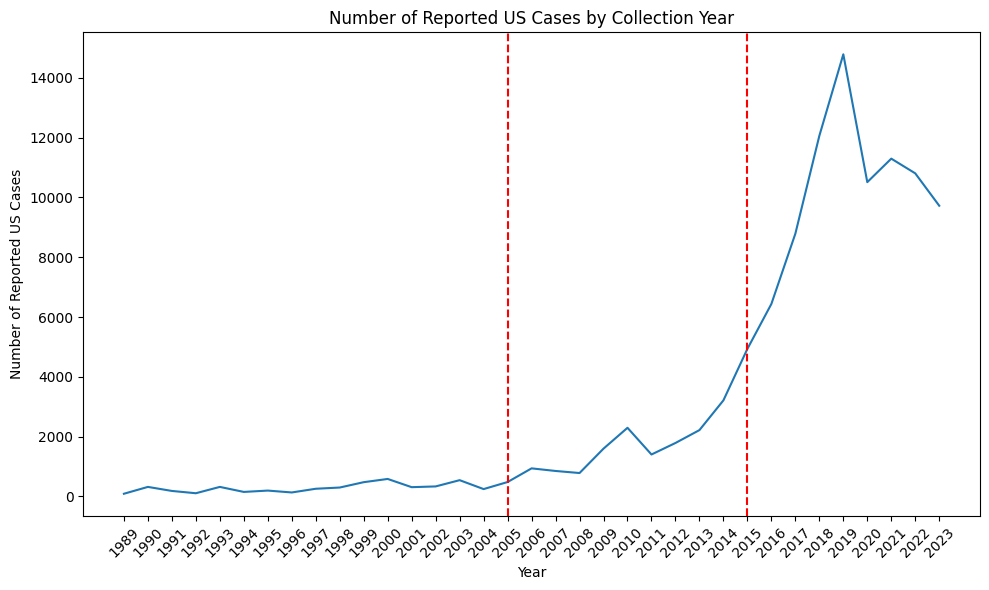

In [29]:
#group by collection_year and count rows
df = df[df['collection_year'] >=1989]
df_grouped = df.groupby('collection_year').size().reset_index(name='count')
df_grouped = df_grouped.sort_values(by='collection_year')
#plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df_grouped['collection_year'], df_grouped['count'])
#make a x-axis tick for each year
plt.xticks(df_grouped['collection_year'], rotation=45)
plt.xlabel('Year')
plt.ylabel('Number of Reported US Cases')
plt.title('Number of Reported US Cases by Collection Year')
plt.tight_layout()
#make a vertical dashed line at 2005 and 2015
plt.axvline(x=2005, color='r', linestyle='--', label='2005')
plt.axvline(x=2015, color='r', linestyle='--', label='2015')
plt.show()





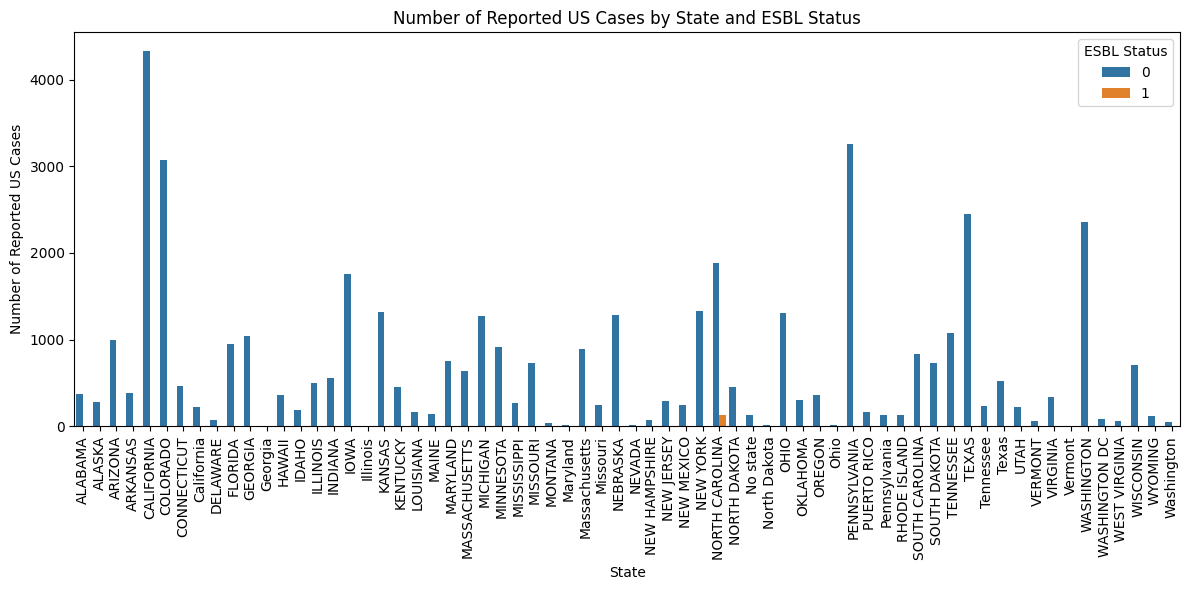

In [34]:
#make a column called is_esbl, where 1 if upper(df['strain]) contains 'ESBL' and 0 otherwise
df['is_esbl'] = df['strain'].fillna('').str.upper().str.contains('ESBL').astype(int)
#group by state and is_esbl and count rows
df_esbl = df.groupby(['usa_state', 'is_esbl']).size().reset_index(name='count')
df_esbl = df_esbl[df_esbl['usa_state'] != 'Unknown']
#make a bar chart of the data
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x='usa_state', y='count', hue='is_esbl', data=df_esbl)
plt.xlabel('State')
plt.ylabel('Number of Reported US Cases')
plt.title('Number of Reported US Cases by State and ESBL Status')
plt.xticks(rotation=90)
plt.legend(title='ESBL Status', loc='upper right')
plt.tight_layout()
plt.show()


In [35]:
df_esbl['usa_state'].value_counts()

usa_state
NORTH CAROLINA    2
MASSACHUSETTS     2
Pennsylvania      2
ALABAMA           1
RHODE ISLAND      1
NEW MEXICO        1
NEW YORK          1
NORTH DAKOTA      1
No state          1
North Dakota      1
OHIO              1
OKLAHOMA          1
OREGON            1
Ohio              1
PENNSYLVANIA      1
PUERTO RICO       1
SOUTH CAROLINA    1
NEW HAMPSHIRE     1
SOUTH DAKOTA      1
TENNESSEE         1
TEXAS             1
Tennessee         1
Texas             1
UTAH              1
VERMONT           1
VIRGINIA          1
Vermont           1
WASHINGTON        1
WASHINGTON DC     1
WEST VIRGINIA     1
WISCONSIN         1
WYOMING           1
NEW JERSEY        1
NEVADA            1
ALASKA            1
NEBRASKA          1
ARIZONA           1
ARKANSAS          1
CALIFORNIA        1
COLORADO          1
CONNECTICUT       1
California        1
DELAWARE          1
FLORIDA           1
GEORGIA           1
Georgia           1
HAWAII            1
IDAHO             1
ILLINOIS          1
INDIANA   